# 01. 대여소별 시간당 수요 예측
시간대별 자전거 대여 수요를 예측합니다 (회귀 문제).

In [1]:
import sys, gc, joblib
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

for font_path in ["/System/Library/Fonts/Supplemental/AppleGothic.ttf", "/Library/Fonts/NanumGothic.ttf"]:
    import pathlib
    if pathlib.Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        plt.rcParams["font.family"] = prop.get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

from src.data_loader import load_processed, save_processed
from src.feature_engineering import build_lag_features
from src.evaluation import regression_report, plot_actual_vs_predicted, plot_feature_importance

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb

pd.set_option("display.float_format", "{:.3f}".format)
print("✅ 준비 완료")

✅ 준비 완료


## 1. 데이터 로드

In [2]:
hourly = load_processed("station_hourly_demand")
print(hourly.head())
print(f"\n대여소 수: {hourly['stn_id'].nunique():,}")
print(f"시간 범위: {hourly['datetime_hour'].min()} ~ {hourly['datetime_hour'].max()}")
print(f"\n대여 건수 통계:")
print(hourly["rent_count"].describe())

📂 Loaded station_hourly_demand.parquet → shape: (3835657, 5)
  stn_id       datetime_hour  rent_count  rtrn_count  net_flow
0  ST-10 2025-10-01 00:00:00       0.000       3.000    -3.000
1  ST-10 2025-10-01 01:00:00       4.000       2.000     2.000
2  ST-10 2025-10-01 02:00:00       1.000       2.000    -1.000
3  ST-10 2025-10-01 03:00:00       1.000       1.000     0.000
4  ST-10 2025-10-01 04:00:00       2.000       0.000     2.000

대여소 수: 2,791
시간 범위: 2025-10-01 00:00:00 ~ 2025-12-31 23:00:00

대여 건수 통계:
count   3835657.000
mean          2.232
std           3.133
min           0.000
25%           1.000
50%           1.000
75%           3.000
max         164.000
Name: rent_count, dtype: float64


## 2. 상위 대여소 필터링 및 피처 엔지니어링

In [4]:
from src.feature_engineering import add_holiday_features, add_cyclical_features

# 상위 100개 대여소 선택
top_stns = hourly.groupby("stn_id")["rent_count"].sum().nlargest(100).index
df_top = hourly[hourly["stn_id"].isin(top_stns)].copy()
print(f"상위 100개 대여소 데이터: {len(df_top):,}행")

# 래그 피처 추가 (336h=2주, 720h=30일 포함)
df_feat = build_lag_features(df_top, target_col="rent_count")

# 시간 피처
df_feat["hour"]       = df_feat["datetime_hour"].dt.hour
df_feat["dow"]        = df_feat["datetime_hour"].dt.dayofweek
df_feat["day"]        = df_feat["datetime_hour"].dt.day
df_feat["month"]      = df_feat["datetime_hour"].dt.month
df_feat["is_weekend"] = (df_feat["dow"] >= 5).astype(int)

# 공휴일 피처 (개천절, 한글날, 크리스마스)
df_feat = add_holiday_features(df_feat, dt_col="datetime_hour")

# 시간/요일 순환 인코딩
df_feat = add_cyclical_features(df_feat)

# 대여소 레이블 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_feat["stn_enc"] = le.fit_transform(df_feat["stn_id"])

# 래그 컬럼 결측치 제거
lag_cols = [c for c in df_feat.columns if c.startswith("lag_") or c.startswith("roll_")]
df_feat = df_feat.dropna(subset=lag_cols)

# net_flow 래그 피처 추가 (대여소별 순유출 과거값)
for lag in [1, 24, 168]:
    df_feat[f"net_flow_lag_{lag}h"] = df_feat.groupby("stn_id")["net_flow"].shift(lag)
netflow_cols = [f"net_flow_lag_{l}h" for l in [1, 24, 168]]
df_feat = df_feat.dropna(subset=netflow_cols)

print(f"피처 엔지니어링 후: {len(df_feat):,}행")
df_feat.head(3)

상위 100개 대여소 데이터: 196,759행


피처 엔지니어링 후: 6,491행


,stn_id,datetime_hour,rent_count,rtrn_count,net_flow,lag_1h,lag_2h,lag_3h,lag_24h,lag_48h,...,is_holiday,is_holiday_eve,hour_sin,hour_cos,dow_sin,dow_cos,stn_enc,net_flow_lag_1h,net_flow_lag_24h,net_flow_lag_168h
24592,ST-1017,2025-11-13 23:00:00,2.000,3.000,-1.000,10.000,12.000,7.000,13.000,10.000,...,0,0,-0.259,0.966,0.434,-0.901,0,7.000,-2.000,22.000
24593,ST-1017,2025-11-14 00:00:00,0.000,1.000,-1.000,2.000,10.000,12.000,12.000,9.000,...,0,0,0.000,1.000,-0.434,-0.901,0,-1.000,0.000,4.000
24594,ST-1017,2025-11-14 01:00:00,2.000,1.000,1.000,0.000,2.000,10.000,7.000,15.000,...,0,0,0.259,0.966,-0.434,-0.901,0,-1.000,2.000,-2.000


## 3. 학습/검증/테스트 분할 (시간순)

In [5]:
# 시간순 분할: 앞 75% 학습, 뒤 25% 테스트
split_idx = int(len(df_feat) * 0.75)
df_train = df_feat.iloc[:split_idx]
df_test  = df_feat.iloc[split_idx:]

FEATURE_COLS = (
    ["stn_enc", "hour", "dow", "day", "month", "is_weekend"]
    + ["is_holiday", "is_holiday_eve"]
    + ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]
    + lag_cols
    + netflow_cols
)

X_train = df_train[FEATURE_COLS]
y_train = df_train["rent_count"]
X_test  = df_test[FEATURE_COLS]
y_test  = df_test["rent_count"]

print(f"학습 데이터: {len(X_train):,}행  |  테스트: {len(X_test):,}행")
print(f"피처 수: {len(FEATURE_COLS)}")
print(f"시간 범위: {df_train['datetime_hour'].min()} ~ {df_test['datetime_hour'].max()}")

학습 데이터: 4,868행  |  테스트: 1,623행
피처 수: 26
시간 범위: 2025-11-08 14:00:00 ~ 2025-12-31 23:00:00


## 4. 베이스라인 모델

In [6]:
# 베이스라인 1: 전체 평균
baseline_mean = np.full(len(y_test), y_train.mean())
r1 = regression_report(y_test, baseline_mean, "평균 예측")

# 베이스라인 2: 168시간 전 (1주일 전) 값 사용
lag168 = df_test["lag_168h"].fillna(y_train.mean())
r2 = regression_report(y_test, lag168, "7일전 래그")

print(f"\n베이스라인 비교: 평균 MAE={r1['MAE']:.3f}, 7일전래그 MAE={r2['MAE']:.3f}")

[평균 예측] MAE=4.305  RMSE=5.605  MAPE=160.1%  R²=-0.0503
[7일전 래그] MAE=5.068  RMSE=7.814  MAPE=157.5%  R²=-1.0411

베이스라인 비교: 평균 MAE=4.305, 7일전래그 MAE=5.068


## 5. LightGBM 모델

In [7]:
model = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)

y_pred = model.predict(X_test).clip(0)
r3 = regression_report(y_test, y_pred, "LightGBM")
print(f"\n개선율 vs 평균 베이스라인: MAE {(1 - r3['MAE']/r1['MAE'])*100:.1f}% 향상")

[100]	valid_0's l1: 2.67708


[LightGBM] MAE=2.674  RMSE=3.705  MAPE=84.8%  R²=0.5412

개선율 vs 평균 베이스라인: MAE 37.9% 향상


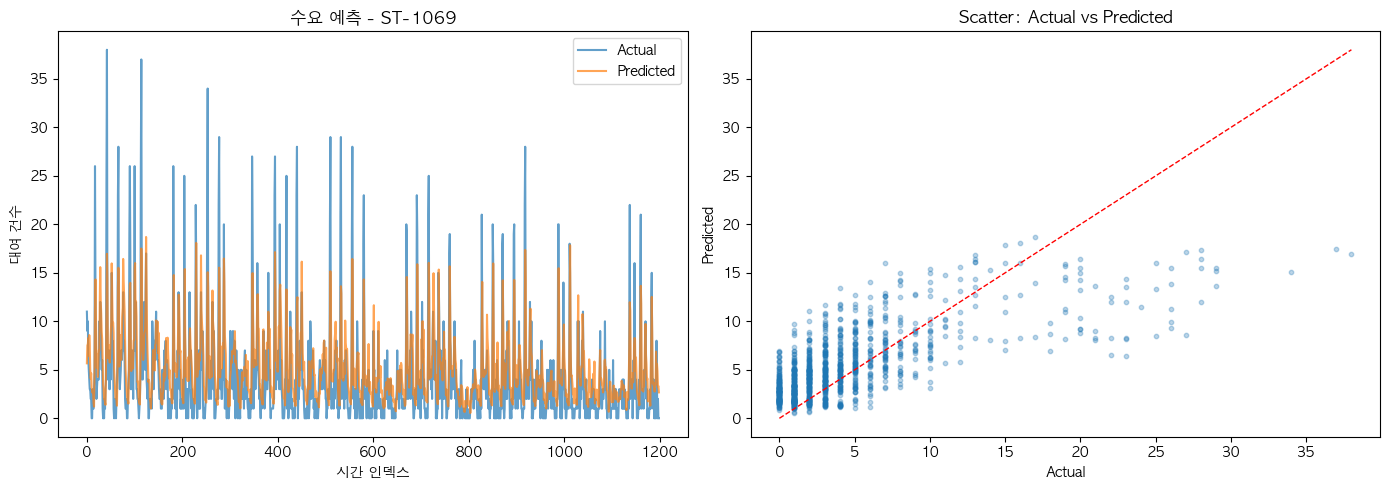

In [8]:
# 특정 대여소의 예측 결과 시각화
stn_sample = df_test["stn_id"].value_counts().index[0]
mask = df_test["stn_id"] == stn_sample
y_true_stn = y_test[mask].values
y_pred_stn = y_pred[mask]

plot_actual_vs_predicted(
    y_true_stn, y_pred_stn,
    title=f"수요 예측 - {stn_sample}",
    xlabel="시간 인덱스",
    ylabel="대여 건수",
    save_name="demand_forecast_sample"
)

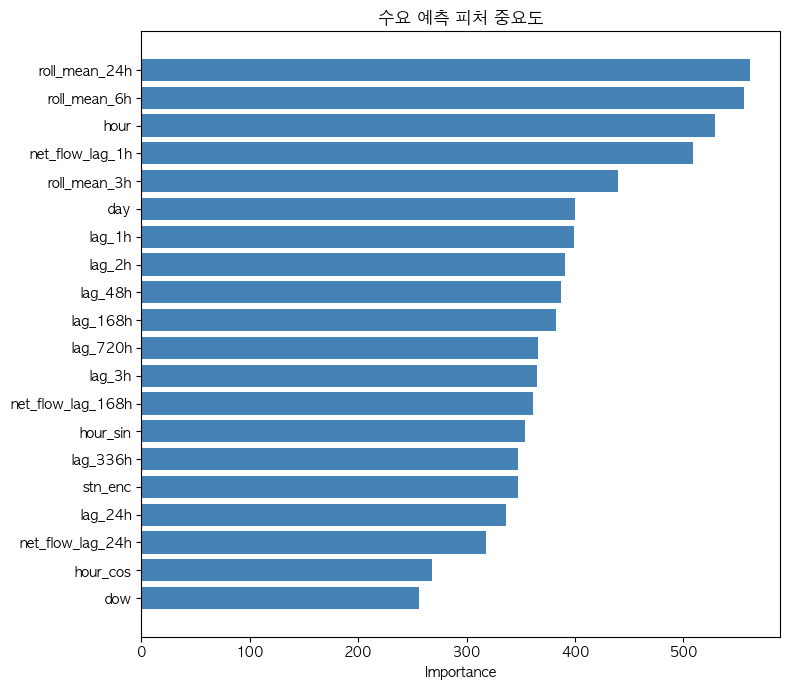

In [9]:
plot_feature_importance(
    model, FEATURE_COLS,
    title="수요 예측 피처 중요도",
    save_name="demand_feature_importance"
)

## 6. 모델 저장

In [10]:
from pathlib import Path
import joblib

model_path = Path("../models/demand/lgbm_demand.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, model_path)
print(f"✅ 모델 저장: {model_path}")

# 결과 요약
results = pd.DataFrame([r1, r2, r3], index=["평균 베이스라인", "7일전 래그", "LightGBM"])
print("\n📊 모델 성능 비교:")
print(results.round(4))

✅ 모델 저장: ../models/demand/lgbm_demand.pkl

📊 모델 성능 비교:
           MAE  RMSE  MAPE(%)     R²
평균 베이스라인 4.305 5.606  160.102 -0.050
7일전 래그   5.068 7.814  157.535 -1.041
LightGBM 2.674 3.705   84.802  0.541
